In [1]:
from scipy.signal import find_peaks, peak_prominences
import numpy as np
import matplotlib.pyplot as plt
import h5py
from hcipy import *
import sys
sys.path.append('/Users/michield/Documents/PhD/Code/KARAOCE/kid_test')
from read_test import *
from fastnoise import NoiseFile
from optimal_filter import *
from scipy.stats import gaussian_kde
%matplotlib widget

ModuleNotFoundError: No module named 'h5py'

In [7]:
def lens(f, o):
    i = 1/(1/f-1/o)
    m = -i/o
    return i, m 

lens(30, 62)


(58.125, -0.9375)

In [2]:
file_loc = "/Users/michield/Documents/PhD/Code/KARAOCE/kid_test/MUX12Dec/"
mapping_filename = "LT402chip1_20251215_trimmed_lenses.txt"

hf_red = file_loc + "pulse.01234.h5"

In [3]:
def pulse_dictionary(h5_filename, mapping_filename, pw=1024):

	with h5py.File(h5_filename, "r") as file:
		
		nr_pixels = len(file['rack_00/channel_00/pulses/']) # Total number of MKID pixels
		lo = file['rack_00/channel_00'].attrs['LO frequency']	# Local Oscillator frequency

		# Frequencies
		dacbin_counts = np.zeros((nr_pixels, 2)) # Total number of counts for each dacbin number
		for i, key in enumerate(file['rack_00/channel_00/pulses/'].keys()):
			pixel_group = file['rack_00/channel_00/pulses/' + key]
			dacbin = pixel_group.attrs['dacbin']
			counts = len(pixel_group)
			dacbin_counts[i, 0] = dacbin
			dacbin_counts[i, 1] = counts

		dacbins = dacbin_counts[:,0]
		f0 = (dacbins / 2**18) + (lo/1000) # Frequency corresponding to dacbin numbers

		# Map to array
		mapping = np.genfromtxt(mapping_filename) # [X Y frequency (during scan)]
		nan_idx = np.isnan(mapping[:,2])
		mapping = mapping[~nan_idx, :]

		dacbin_map = np.empty((20, 20)) # X, Y grid
		dacbin_map[:] = np.nan # Array with NaNs
		mkid_img = dacbin_map.copy()
		for i, f in enumerate(f0):
			val, idx = find_nearest(mapping[:,2], f) # find which mapping frequency is closest to dacbin frequency
			
			pixel_dacbin = dacbin_counts[i,0] # dacbin
			pixel_counts = dacbin_counts[i,1]

			x = mapping[idx,0]
			y = mapping[idx,1]

			dacbin_map[int(x), int(y)] = pixel_dacbin
			mkid_img[int(x), int(y)] = pixel_counts

		# Pulses per pixel
		pixel_keys = dict(file['rack_00']['channel_00']['pulses']).keys()
		pulse_data = dict.fromkeys(pixel_keys, np.array([]))

		for i, pixel_key in enumerate(pixel_keys):

			pixel_dacbin = file['rack_00']['channel_00']['pulses'][pixel_key].attrs['dacbin']
			pixel_idx = np.where(dacbin_map==pixel_dacbin)

			pulse_keys = dict(file['rack_00']['channel_00']['pulses'][pixel_key]).keys()
			pixel_pulses = np.zeros((len(pulse_keys), pw))
			for i, key in enumerate(pulse_keys):
				pulse = file['rack_00']['channel_00']['pulses'][pixel_key][key][()]
				pixel_pulses[i] = (pulse[:,0] / 2**15) * np.pi * (-1)

			pulse_data[pixel_key] = {'xy': pixel_idx, 'pulses': pixel_pulses, 'dacbin': pixel_dacbin}

	return pulse_data

def dictionary_to_image(pulse_dictionary):

	arr = np.zeros((20,20))
	arr[:] = np.nan
	for key in pulse_dictionary.keys():
		arr[pulse_dictionary[key]['xy']] = len(pulse_dictionary[key]['pulses'])

	return arr

In [ ]:
def index_to_key(pixel_index, pulse_data):
	for pixel_key in pulse_data.keys():
		xy_coord = pulse_data[pixel_key]['xy']
		if xy_coord == pixel_index:
			return pixel_key

def gaussian(x, amp, mean, sigma):
	return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

def filter_and_align_peaks(
	arrays,
	window_size=256,
	peak_index=49,
	**peak_kwargs
):
	"""
	Keep arrays with exactly one peak and extract a subset
	such that the peak is centered at a fixed index.

	Parameters
	----------
	arrays : array-like, shape (N, M)
		Collection of 1D arrays of equal length.
	window_size : int
		Length of the extracted subset.
	peak_index : int
		Index where the peak should land (50th sample -> 49).
	peak_kwargs : dict
		Passed to scipy.signal.find_peaks (e.g. prominence).

	Returns
	-------
	centered_arrays : ndarray, shape (K, window_size)
		Filtered and centered arrays.
	peak_locations : ndarray
		Original peak indices in the full arrays.
	"""
	arrays = np.asarray(arrays)
	centered = []
	peak_locations = []

	for arr in arrays:
		peaks, _ = find_peaks(arr, **peak_kwargs)

		# Keep only arrays with exactly one peak
		if len(peaks) != 1:
			continue

		peak = peaks[0]
		start = peak - peak_index
		end = start + window_size

		# Ensure window is fully inside the array
		if start < 0 or end > len(arr):
			continue

		centered.append(arr[start:end])
		peak_locations.append(peak)

	return np.array(centered), np.array(peak_locations)

def clean_pulses(pulse_data):

	copy_pulse_data = {}
	for pk in pulse_data.keys():
		pixel_pulses = pulse_data[pk]['pulses']
		new_pulses, _ = filter_and_align_peaks(pixel_pulses, window_size=256, peak_index=49, prominence=0.9)
		  
		copy_pulse_data[pk] = {'xy': pulse_data[pk]['xy'], 'pulses': new_pulses, 'dacbin': pulse_data[pk]['dacbin']}
		  
	return copy_pulse_data

In [13]:
def kde_fwhm(data, bandwidth='scott', grid_size=2000):
    """
    Estimate KDE and compute Full Width at Half Maximum (FWHM).

    Parameters
    ----------
    data : array-like (1D)
    bandwidth : str or float
        Passed to gaussian_kde (if float, overrides method).
    grid_size : int
        Resolution of evaluation grid.

    Returns
    -------
    fwhm : float
    x_grid : ndarray
    kde_vals : ndarray
    peak_x : float
    """
    data = np.asarray(data)

    # Fit KDE
    kde = gaussian_kde(data, bw_method=bandwidth)

    # Evaluation grid
    x_min, x_max = data.min(), data.max()
    padding = 0.1 * (x_max - x_min)
    x_grid = np.linspace(x_min - padding, x_max + padding, grid_size)

    kde_vals = kde(x_grid)

    # Peak
    peak_idx = np.argmax(kde_vals)
    peak_x = x_grid[peak_idx]
    peak_val = kde_vals[peak_idx]

    half_max = peak_val / 2.0

    # Find indices where KDE crosses half max
    above = kde_vals >= half_max

    # Find left and right crossing points
    indices = np.where(np.diff(above.astype(int)) != 0)[0]

    if len(indices) < 2:
        raise ValueError("Could not find two half-max crossings. Try adjusting bandwidth or grid size.")

    # interpolate crossings for better accuracy
    def interpolate(i):
        x0, x1 = x_grid[i], x_grid[i+1]
        y0, y1 = kde_vals[i], kde_vals[i+1]
        return x0 + (half_max - y0) * (x1 - x0) / (y1 - y0)

    left_i = indices[0]
    right_i = indices[-1]

    left_x = interpolate(left_i)
    right_x = interpolate(right_i)

    fwhm = right_x - left_x

    return fwhm, x_grid, kde_vals, peak_x

In [5]:
def pulse_heights_optimal_filter(pulse_data, noise_data, pixel_key=None):

	if pixel_key:
		pixel_pulses = pulse_data[pixel_key]['pulses']
		# pulses_max = np.max(pixel_pulses, axis=1)
	else:
		copy_pulse_data = {}
		for pk in pulse_data.keys():
			pixel_pulses = pulse_data[pk]['pulses']
			if pixel_pulses.size==0:
				pulses_optfil = np.array([])
			else:

				pixel_pulses = pulse_data[pk]['pulses']

				pixel_dacbin = pulse_data[pk]['dacbin']
				pixel_noise = noise_data[pixel_dacbin].allPhaseData * (-1)	

				norm_pulse, norm_pulse_fft, norm_pulse_psd = pulse_model(pixel_pulses, pw_filtered, sf)
				noise_psd, freqs = noise_model(pixel_noise, pw_filtered, sf, threshold=None, nr_req_segments=800)
				opt_filter = optimal_filter(norm_pulse_fft, noise_psd, exclude_dc)

				pulses_optfil = pulse_height(pixel_pulses, len_onesided_filtered, opt_filter, exclude_dc)

				# R_SN
				# hist, bins = np.histogram(pulses_optfil, bins='doane', range=None)
				# H_bar = bins[np.argmax(hist)]
				
				if len(pulses_optfil)>40:
					fwhm, x_grid, kde_vals, H_bar = kde_fwhm(pulses_optfil)
				else:
					H_bar = np.average(pulses_optfil)

				# df = 1 / (pw * (1/sf))
				# R_snr = (H_bar / (2 * np.sqrt(2*np.log(2)))) * np.sqrt(np.trapz((np.abs(norm_pulse_fft)**2 / noise_psd), freqs, df))
				R_snr = (H_bar / (2 * np.sqrt(2*np.log(2)))) * np.sqrt(np.sum((norm_pulse_psd / noise_psd)))
			
			copy_pulse_data[pk] = {'xy': pulse_data[pk]['xy'], 'pulses': pulse_data[pk]['pulses'], 'pulse_heights': pulses_optfil, 'dacbin': pulse_data[pk]['dacbin'], 'R_snr': R_snr}
			
		return copy_pulse_data

	return pulses_optfil

In [ ]:
def energy_calibration(pulse_dictionary_red, pulse_dictionary_blue):
 
    copy_pulse_data_r = pulse_dictionary_red.copy()
    copy_pulse_data_b = pulse_dictionary_blue.copy()
 
    for key in pulse_dictionary_red.keys():
        if len(pulse_dictionary_red[key]['gaussian']) != 0:
            
            pulse_heights_red = pulse_dictionary_red[key]['pulse_heights']
            pulse_heights_blue = pulse_dictionary_blue[key]['pulse_heights']
 
            # build linear model
            fwhm, x_grid, kde_vals, peak_phase_red = kde_fwhm(pulse_heights_red)
            fwhm, x_grid, kde_vals, peak_phase_blue = kde_fwhm(pulse_heights_blue)
 
            T = np.array([peak_phase_red, peak_phase_blue]) # response
            E = np.array([1.9525, 2.7552]) # eV
            m, b = np.polyfit(T, E, 1)
            
            copy_pulse_data_r[key]['lin_calib'] = [m,b]
            copy_pulse_data_b[key]['lin_calib'] = [m,b]
 
    return  copy_pulse_data_r, copy_pulse_data_b
 
def rad_to_energy(data, m, b):
 
            predict = lambda x: m * x + b # response to eV
 
            # phase to energy
            energies = predict(data)
 
            return energies
 
def energy_resolution_image(pulse_dic, key=None):
 
            # # estimate FWHM
            # fwhm_r, x_grid, kde_vals, peak_energy_red = kde_fwhm(energies_red)
            # fwhm_b, x_grid, kde_vals, peak_energy_blue = kde_fwhm(energies_blue)
 
            # # write resolving power
            # arr[pulse_dictionary_red[key]['xy'][0], pulse_dictionary_red[key]['xy'][1], 0] = peak_energy_red / fwhm_r
            # arr[pulse_dictionary_blue[key]['xy'][0], pulse_dictionary_blue[key]['xy'][1], 1] = peak_energy_blue / fwhm_b
    if key is not None:
        pulse_heights = pulse_dic[key]['pulse_heights']
        m = pulse_dic[key]['lin_calib'][0]
        b = pulse_dic[key]['lin_calib'][1]
        energies = rad_to_energy(pulse_heights, m, b)
        
        return energies
    else:
    
        arr = np.zeros((20,20))
        arr[:] = np.nan
        for key in pulse_dic.keys():
            if 'lin_calib' in pulse_dic[key]:
                pulse_heights = pulse_dic[key]['pulse_heights']
                m = pulse_dic[key]['lin_calib'][0]
                b = pulse_dic[key]['lin_calib'][1]
                energies = rad_to_energy(pulse_heights, m, b)
                fwhm, x_grid, kde_vals, peak_x = kde_fwhm(energies)
                arr[pulse_dic[key]['xy']] = peak_x / fwhm
 
        return arr

In [6]:
noise_1 = NoiseFile(file_loc + "fastreadout_noise.00082.h5")

--- done loading noise data ---          


In [9]:
pw = 1024 # pulse width
sf = 1e+9/1024 # sample frequency
exclude_dc = True
len_onesided = round(pw / 2) + 1
pw_filtered = 256
len_onesided_filtered = round(pw_filtered / 2) + 1

In [10]:
# Put detector pulse data in dictionary format
pulses_red = pulse_dictionary(hf_red, file_loc+mapping_filename, pw=1024)

In [11]:
# clean pulses
pulses_red = clean_pulses(pulse_data=pulses_red)

In [16]:
# estimate pulse heights
pulses_red_ph = pulse_heights_optimal_filter(pulses_red, noise_1)

In [17]:
# to image
image = dictionary_to_image(pulses_red_ph)

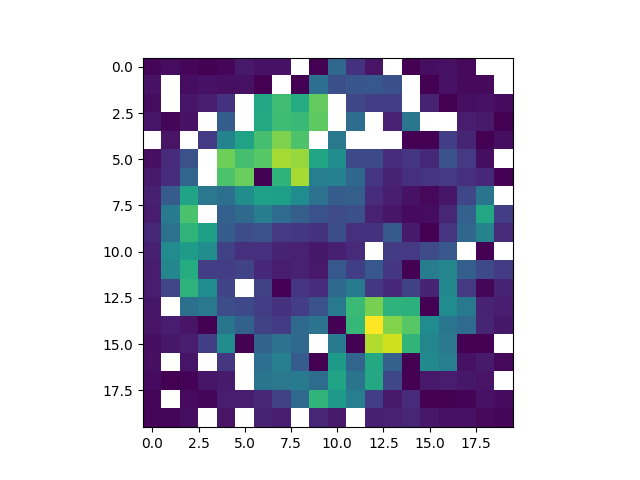

In [18]:
plt.figure()
plt.imshow(image)